# Crypto 5min Backtest - FinRL Tutorial
Backtest trained reinforcement learning agents.

**Prerequisites**: Run Part 1 (Data) and Part 2 (Train) notebooks first.

# Part 1. Import Packages

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import A2C, PPO, DDPG, TD3, SAC

from finrl.config import TRAINED_MODEL_DIR
from finrl.meta.env_cryptocurrency_trading.env_multiple_crypto import CryptoEnv

import gymnasium as gym
from gymnasium import spaces

print("Packages loaded!")

Packages loaded!


# Part 2. Load Test Data

In [32]:
# Load data from Part 1
data = np.load('crypto_5m_data.npz', allow_pickle=True)

test_price = data['test_price']
test_tech = data['test_tech']
crypto_pairs = data['crypto_pairs']

print(f"Test data: {len(test_price)} samples")
print(f"Number of coins: {test_price.shape[1]}")
print(f"Coin list: {crypto_pairs}")

Test data: 1706 samples
Number of coins: 5
Coin list: ['BTC/USDT' 'ETH/USDT' 'BNB/USDT' 'XRP/USDT' 'SOL/USDT']


# Part 3. Setup Gym Environment

In [33]:
class CryptoEnvGym(gym.Env):
    """Wrap CryptoEnv with Gymnasium interface"""
    
    def __init__(self, config, **kwargs):
        super().__init__()
        self.env = CryptoEnv(config, **kwargs)
        
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, 
            shape=(self.env.state_dim,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=-1, high=1, 
            shape=(self.env.action_dim,), dtype=np.float32
        )
    
    def reset(self, seed=None, options=None):
        state = self.env.reset(seed=seed, options=options)
        return state, {}
    
    def step(self, action):
        state, reward, done, info = self.env.step(action)
        return state, reward, done, False, info or {}

# Create test environment
test_config = {
    "price_array": test_price,
    "tech_array": test_tech,
}

env_test = CryptoEnvGym(
    config=test_config,
    lookback=1,
    initial_capital=1_000_000,
    buy_cost_pct=0.001,
    sell_cost_pct=0.001,
)

print(f"Test environment created!")
print(f"Max Steps: {env_test.env.max_step}")

Test environment created!
Max Steps: 1704


# Part 4. Load Trained Models

In [34]:
# Select algorithms to use
if_using_a2c = True
if_using_ppo = True
if_using_ddpg = True
if_using_td3 = True
if_using_sac = True

# Load models
models = {}

if if_using_a2c:
    try:
        models['A2C'] = A2C.load(TRAINED_MODEL_DIR + "/crypto_a2c")
        print("A2C model loaded")
    except:
        print("A2C model not found")

if if_using_ppo:
    try:
        models['PPO'] = PPO.load(TRAINED_MODEL_DIR + "/crypto_ppo")
        print("PPO model loaded")
    except:
        print("PPO model not found")

if if_using_ddpg:
    try:
        models['DDPG'] = DDPG.load(TRAINED_MODEL_DIR + "/crypto_ddpg")
        print("DDPG model loaded")
    except:
        print("DDPG model not found")

print(f"\nLoaded models: {list(models.keys())}")

A2C model loaded
PPO model loaded
DDPG model loaded

Loaded models: ['A2C', 'PPO', 'DDPG']


# Part 5. Run Backtest

In [35]:
def run_backtest(model, env_config, model_name="Model"):
    """Run model backtest"""
    
    # Create new environment
    env = CryptoEnvGym(
        config=env_config,
        lookback=1,
        initial_capital=1_000_000,
        buy_cost_pct=0.001,
        sell_cost_pct=0.001,
    )
    
    # Initialize
    obs, _ = env.reset()
    done = False
    
    # Record lists
    account_values = [1_000_000]  # Initial capital
    actions_list = []
    
    step = 0
    while not done:
        # Predict action with model
        action, _ = model.predict(obs, deterministic=True)
        
        # Step in environment
        obs, reward, done, truncated, info = env.step(action)
        
        # Record current asset value
        current_value = env.env.total_asset
        account_values.append(current_value)
        actions_list.append(action.copy())
        
        step += 1
        if step % 500 == 0:
            print(f"{model_name} - Step {step}: Asset = ${current_value:,.0f}")
    
    # Create result DataFrame
    df_account = pd.DataFrame({
        'step': range(len(account_values)),
        'account_value': account_values
    })
    
    df_actions = pd.DataFrame(actions_list)
    
    # Final return
    final_return = (account_values[-1] / account_values[0] - 1) * 100
    print(f"\n{model_name} Final Return: {final_return:.2f}%")
    print(f"Final Asset: ${account_values[-1]:,.0f}")
    
    return df_account, df_actions

In [36]:
# Run backtest for each model
results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"{name} Backtest Start")
    print(f"{'='*50}")
    
    df_account, df_actions = run_backtest(model, test_config, name)
    results[name] = {
        'account': df_account,
        'actions': df_actions
    }


A2C Backtest Start
A2C - Step 500: Asset = $953,303
A2C - Step 1000: Asset = $943,596
A2C - Step 1500: Asset = $941,826

A2C Final Return: -6.17%
Final Asset: $938,263

PPO Backtest Start
PPO - Step 500: Asset = $991,878
PPO - Step 1000: Asset = $989,346
PPO - Step 1500: Asset = $988,140

PPO Final Return: -1.36%
Final Asset: $986,388

DDPG Backtest Start
DDPG - Step 500: Asset = $948,094
DDPG - Step 1000: Asset = $931,246
DDPG - Step 1500: Asset = $908,088

DDPG Final Return: -9.10%
Final Asset: $908,957


# Part 6. Buy & Hold Baseline

In [37]:
# Buy & Hold strategy (equal weight investment)
initial_capital = 1_000_000
n_coins = test_price.shape[1]

# Equal investment per coin
initial_shares = initial_investment_per_coin / test_price[0]

# Portfolio value at each time
buy_hold_values = (test_price * initial_shares).sum(axis=1)

df_buy_hold = pd.DataFrame({
    'step': range(len(buy_hold_values)),
    'account_value': buy_hold_values
})

buy_hold_return = (buy_hold_values[-1] / buy_hold_values[0] - 1) * 100
print(f"Buy & Hold Final Return: {buy_hold_return:.2f}%")
print(f"Final Asset: ${buy_hold_values[-1]:,.0f}")

Buy & Hold Final Return: -7.77%
Final Asset: $922,307


# Part 7. Visualization

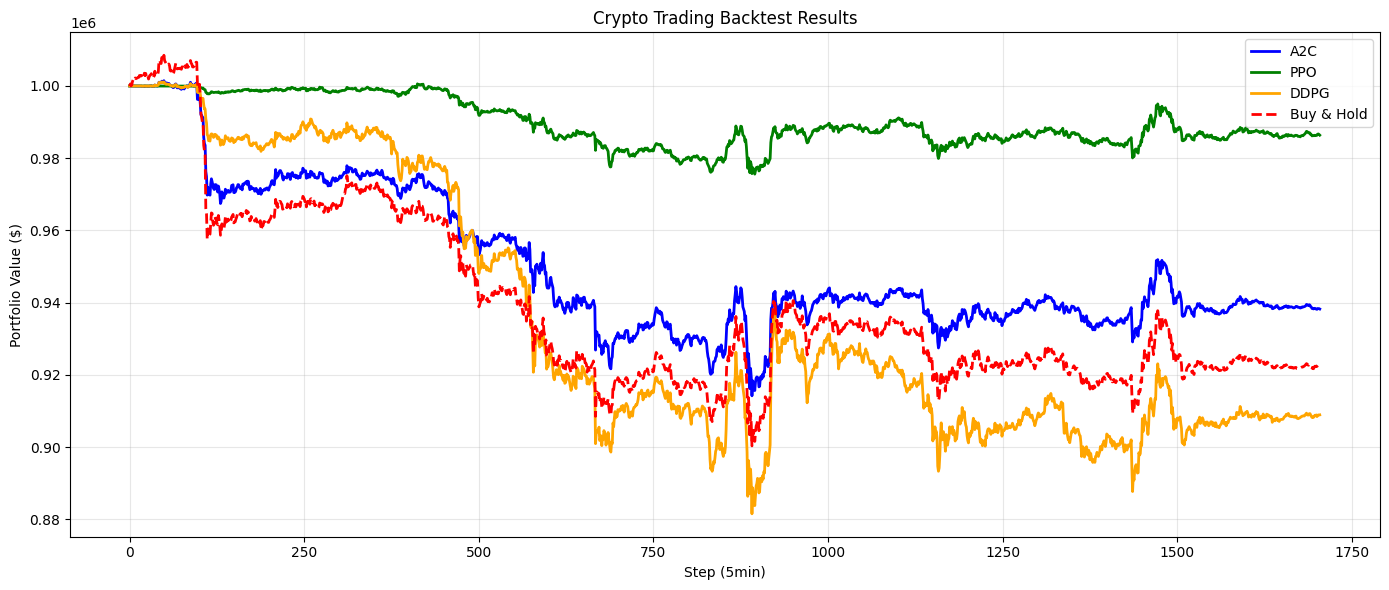

In [38]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))

# 각 모델의 자산 가치 플롯
colors = {'A2C': 'blue', 'PPO': 'green', 'DDPG': 'orange', 'TD3': 'purple', 'SAC': 'brown'}

for name, data in results.items():
    plt.plot(data['account']['step'], data['account']['account_value'], 
             label=name, color=colors.get(name, 'gray'), linewidth=2)

# Buy & Hold 기준선
plt.plot(df_buy_hold['step'], df_buy_hold['account_value'], 
         label='Buy & Hold', color='red', linestyle='--', linewidth=2)

plt.xlabel('Step (5min)')
plt.ylabel('Portfolio Value ($)')
plt.title('Crypto Trading Backtest Results')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
# 수익률 비교 표
summary = []

for name, data in results.items():
    account = data['account']['account_value']
    total_return = (account.iloc[-1] / account.iloc[0] - 1) * 100
    max_value = account.max()
    min_value = account.min()
    
    summary.append({
        'Model': name,
        'Final Value ($)': f"{account.iloc[-1]:,.0f}",
        'Total Return (%)': f"{total_return:.2f}",
        'Max Value ($)': f"{max_value:,.0f}",
        'Min Value ($)': f"{min_value:,.0f}",
    })

# Buy & Hold 추가
summary.append({
    'Model': 'Buy & Hold',
    'Final Value ($)': f"{buy_hold_values[-1]:,.0f}",
    'Total Return (%)': f"{buy_hold_return:.2f}",
    'Max Value ($)': f"{buy_hold_values.max():,.0f}",
    'Min Value ($)': f"{buy_hold_values.min():,.0f}",
})

df_summary = pd.DataFrame(summary)
print("\n" + "="*60)
print("Backtest Results Summary")
print("="*60)
print(df_summary.to_string(index=False))


Backtest Results Summary
     Model Final Value ($) Total Return (%) Max Value ($) Min Value ($)
       A2C         938,263            -6.17     1,001,467       914,235
       PPO         986,388            -1.36     1,000,594       975,604
      DDPG         908,957            -9.10     1,001,142       881,573
Buy & Hold         922,307            -7.77     1,008,506       900,363


# Part 8. Individual Crypto Price Movement

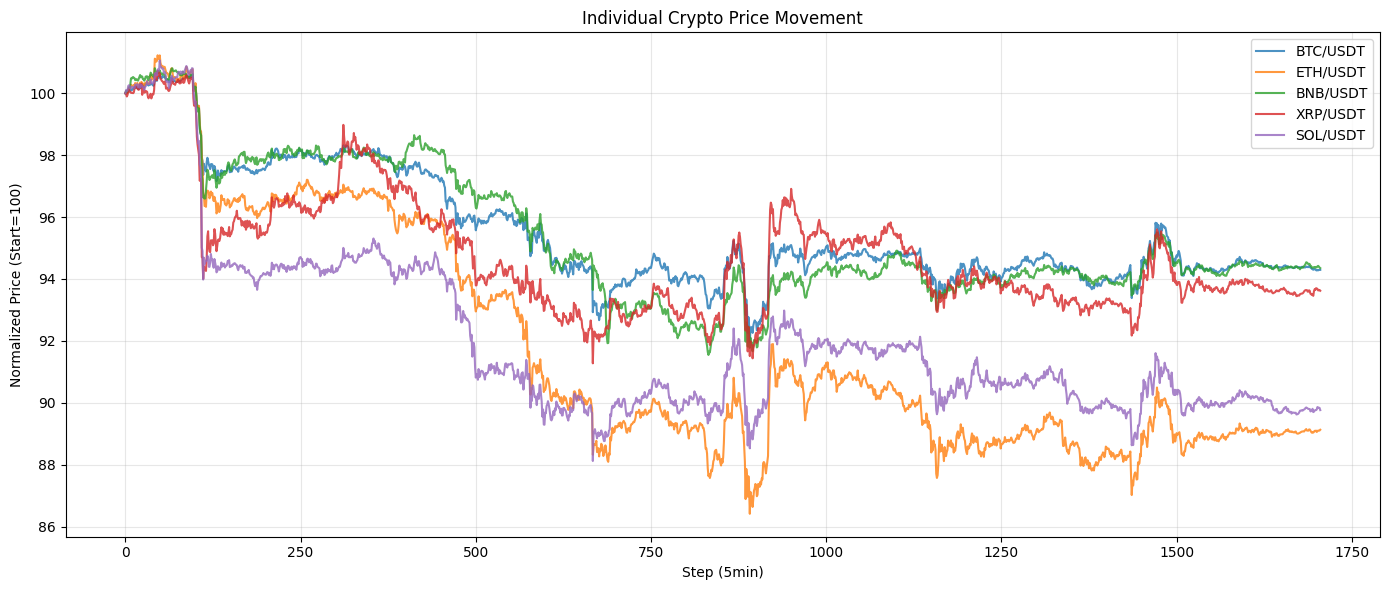

In [40]:
# 각 코인의 가격 변화율
plt.figure(figsize=(14, 6))

for i, pair in enumerate(crypto_pairs):
    prices = test_price[:, i]
    normalized = prices / prices[0] * 100  # 100을 기준으로 정규화
    plt.plot(normalized, label=pair, alpha=0.8)

plt.xlabel('Step (5min)')
plt.ylabel('Normalized Price (Start=100)')
plt.title('Individual Crypto Price Movement')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()